If needed, in order to tranform the jupyter notebook file into a python file, you can use the following command in a terminal :

jupyter nbconvert --to python filename.ipynb

# These are some tests done on a manually-indexed pandas dataframe in order to test the algorithm and see if it is efficient. 
This dataframe has to contained the columns "event_start" and "event_end" that store the start index and the end index of the action-window. In order to know if the algorithm is efficient or not, we compare the center of the predicted action-window to the center of the annotated action-window. We consider that the smaller is the difference, the better the algorithm is.

### Importing of the librairies and the functions of the movement_detection.py file :

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from movement_detection import *

### Loading the dataset from the file path and eventually filtering rows to keep only fall signal of good quality

In [2]:
file_path = "..\\data\\26_05_21.pkl_annotated.pkl"
df = load_dataset(file_path)
df = df.drop(['event_start','event_end'], axis=1)
filters = {
        "segment_type": "action",
        "action": "fall",
        "label": "fall",
        "non_acceptable_signal_quality": False}
for col, target_val in filters.items():
    if col in df.columns and target_val in df[col].unique():
        df = df[df[col] == target_val] 
df = df.reset_index(drop=True)
new_file_path = change_file_name(file_path)

Loading data from: ..\data\26_05_21.pkl_annotated.pkl
Saving the new dataset to a new file dynamically named based on the parameters...


### Changing the CSI signal in order to apply some preprocessing method and adding them to the dataset in the "CSI_processed" column

In [3]:
df = change_CSI_processed(df, remove_null = True, apply_gain = True, denoise = True, bandpass = True, low_freq=0.5, high_freq=10.0, standardize = False, denoise_method = "hampel_filter")
#df = apply_lowpass_filter_row(df, cutoff_freq=10, fs=100.0)

Preprocessing CSI samples from the dataset...


### Plotting an example of CSI processed signal

Affichage du premier exemple


C:\Users\brice\Desktop\Brice\Centrale Supelec\1ère année\Stage Zoe Care\Zoe_Care_work\Movement_Detection_Folders\movement_detection\src\movement_detection\movement_detection.py:1134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


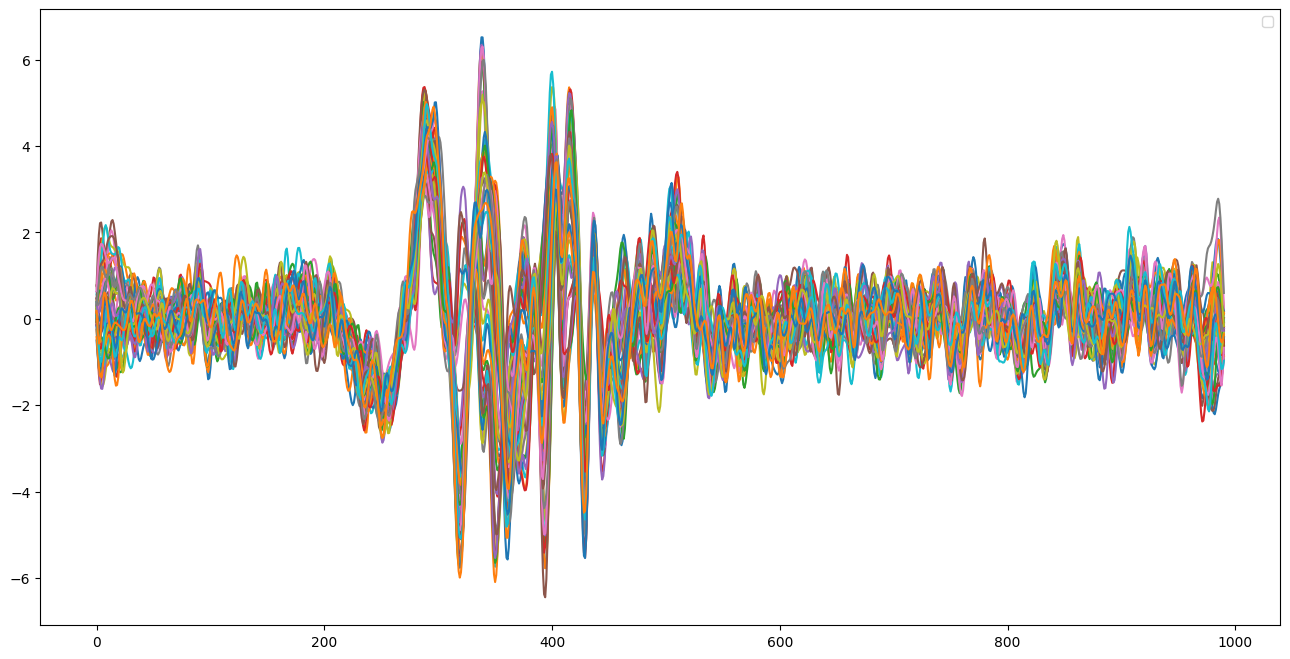

In [4]:
plot_csi_processed_sample(df, index=0)

### Findind every window above the 65 percentile regarding the variance of amplitude for each subcarrier on a 300-packets window (value chosen as example)

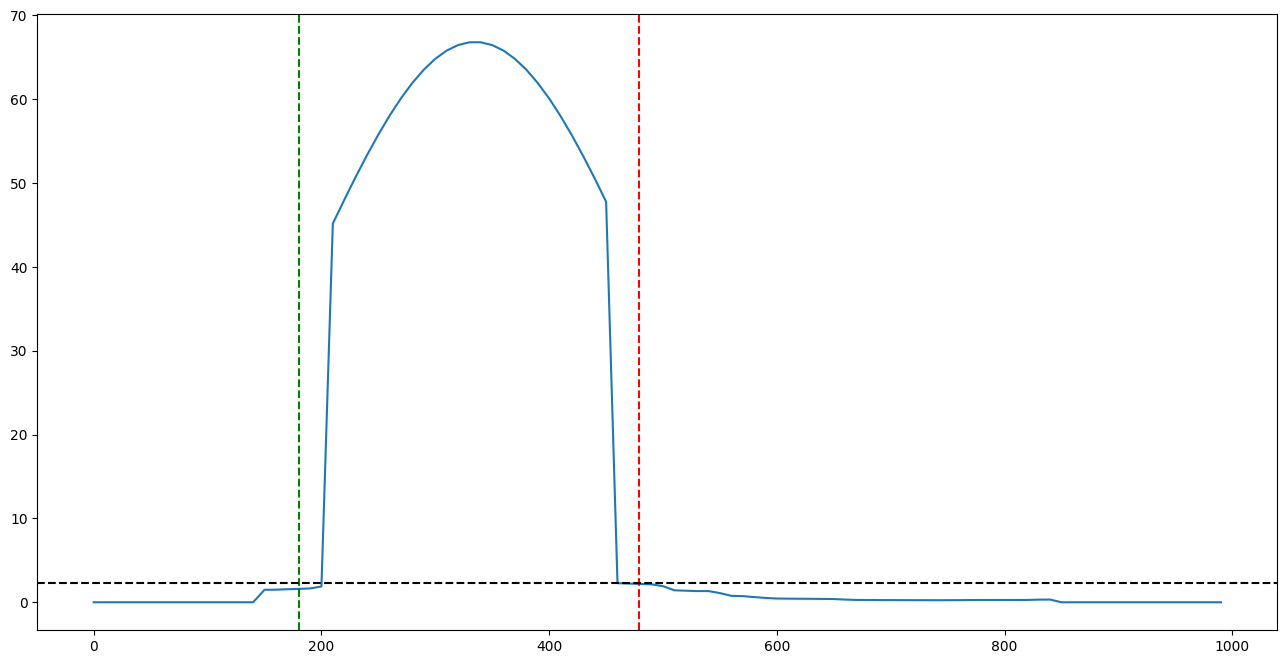

In [5]:
step =10
candidate_windows, variances, p_threshold = find_candidate_windows(df["CSI_processed"][0], window_size=300, band=None, step=step, percentile=35, threshold=None, quietest=False, method="amplitude")
#find_candidate_windows_on_mean_variance_amplitude_per_subcarrier(df["CSI_processed"][0], window_size=400, step=10, percentile=5, quietest=False)
best_index_window = np.argmax([window[2] for window in candidate_windows])
plot_variance(candidate_windows[best_index_window], variances, p_threshold, step=step)
if df.columns.isin(["event_start", "event_end"]).any():
    print("Time distance index : ", abs((candidate_windows[best_index_window][0]-df["event_start"][0]+candidate_windows[best_index_window][1]-df["event_end"][0])//2))

### Findind every window above the 65 percentile regarding the variance of turbulence for each packet on a 300-packets window (value chosen as example)
Here, as gain_locked=True, the turbulence is calculated as the standard deviation of all the amplitude of subcarriers for a fixed packet.

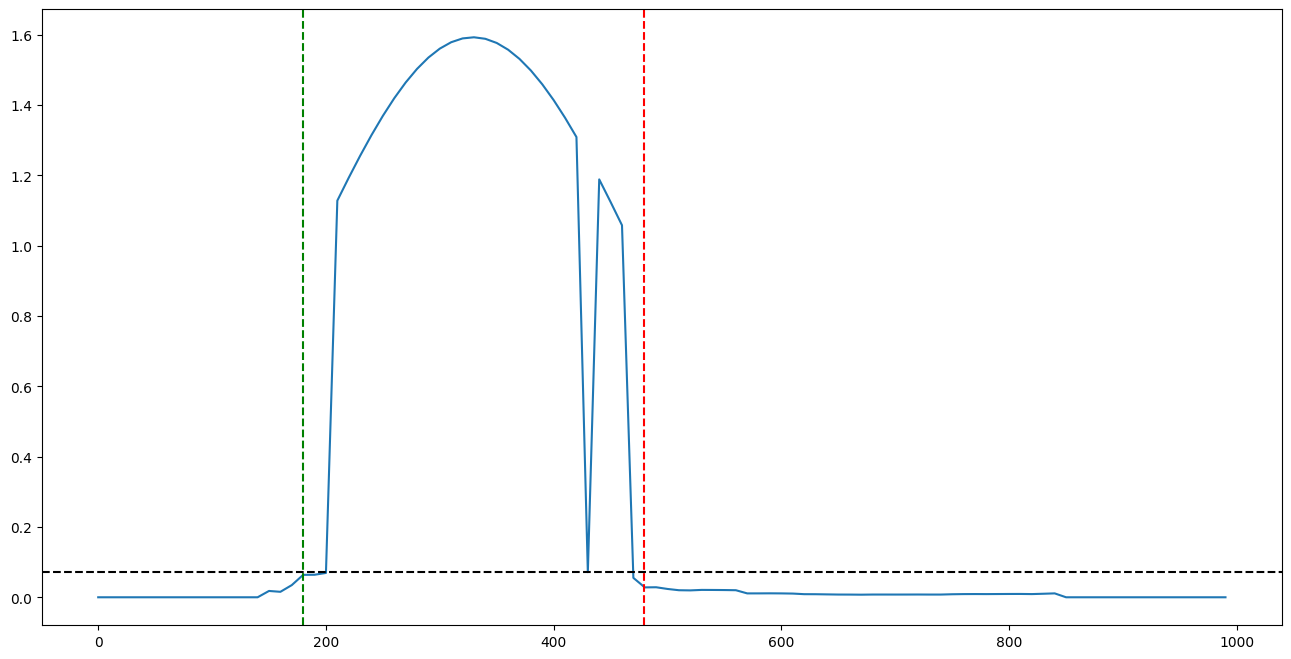

In [6]:
step = 10
candidate_windows, variances, p_threshold = find_candidate_windows(df["CSI_processed"][0], window_size=300, band=None, step=step, percentile=35, threshold=None, quietest=False, method="turbulence")
best_index_window = np.argmax([window[2] for window in candidate_windows])
plot_variance(candidate_windows[best_index_window], variances, p_threshold, step=step)
if df.columns.isin(["event_start", "event_end"]).any():
    print("Time distance index: ",abs((candidate_windows[best_index_window][0]-df["event_start"][0]+candidate_windows[best_index_window][1]-df["event_end"][0])//2))
    #print(f"Time distance index : {abs((candidate_windows[best_index_window][0]-df["event_start"][0]))}")#+candidate_windows[best_index_window][1]-df["event_end"][0])//2)}")
    #print(f"Time distance index : {abs((candidate_windows[best_index_window][0]-df["event_start"][0]+candidate_windows[best_index_window][1]-df["event_end"][0])//2)}")

### Findind every window above the 65 percentile regarding the variance of turbulence for each packet on a 300-packets window (value chosen as example)
Here, as gain_locked=False, the turbulence is calculated as the standard deviation of all the amplitude of subcarriers for a fixed packet divided by its mean.

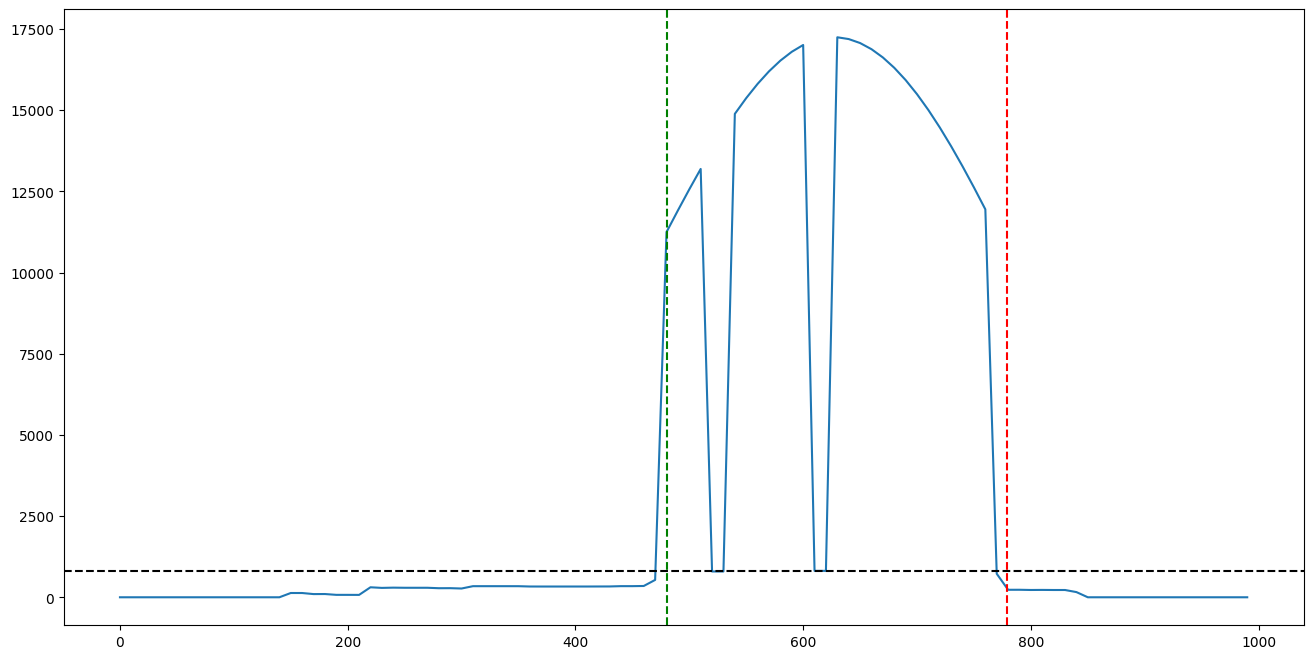

In [7]:
step = 10
candidate_windows, variances, p_threshold = find_candidate_windows(df["CSI_processed"][0], gain_locked=False, window_size=300, band=None, step=step, percentile=35, threshold=None, quietest=False, method="turbulence")
best_index_window = np.argmax([window[2] for window in candidate_windows])
plot_variance(candidate_windows[best_index_window], variances, p_threshold, step=step)
if df.columns.isin(["event_start", "event_end"]).any():
    print("Time distance index: ",abs((candidate_windows[best_index_window][0]-df["event_start"][0]+candidate_windows[best_index_window][1]-df["event_end"][0])//2))

### Findind every window above the 65 percentile regarding the variance of turbulence for each packet on a 300-packets window (value chosen as example) and applying weights to the selected windows following a gaussian function in order to maximize the values of the most centered selected windows.

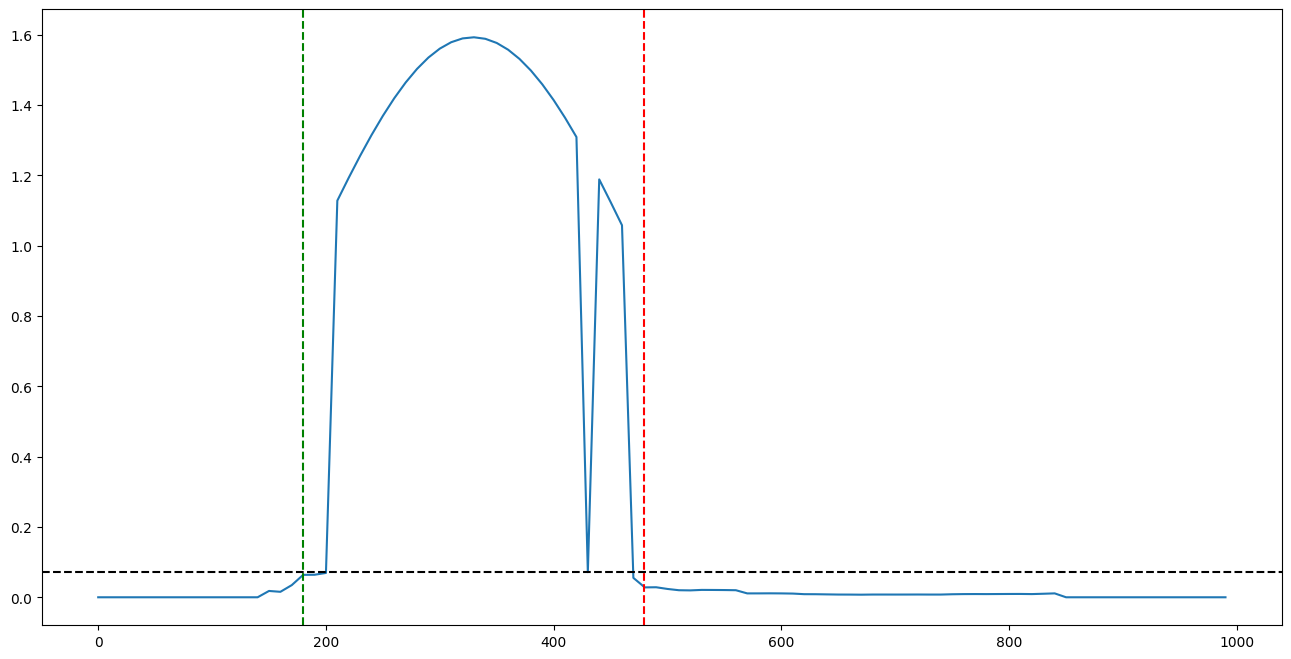

In [8]:
step = 10
candidate_windows, metrics, p_threshold = find_candidate_windows(df["CSI_processed"][0], window_size=300, band=None, step=step, percentile=35, threshold=None, quietest=False, method="turbulence", weighted=True, sigma=12)
best_index_window = np.argmax([window[2] for window in candidate_windows])
plot_variance(candidate_windows[best_index_window], metrics, p_threshold, step=step)
if df.columns.isin(["event_start", "event_end"]).any():
    print("Time distance index: ",abs((candidate_windows[best_index_window][0]-df["event_start"][0]+candidate_windows[best_index_window][1]-df["event_end"][0])//2))

### Selecting the quietest window (containing only ambient noise), choosing four bands of 12 high-quality subcarriers based on three nbvi scores calculated for each subcarrier and four selection methods, and finally selecting a band with a low false positive rate in motion detection.

In [9]:
print("\n[Step 1] Choosing the quietest window...")
# Step 1 : Select the best (quietest) window by calculating the variance of turbulence
csi_data = df["CSI_processed"][0]
candidate_windows, variances, p_threshold = find_candidate_windows(csi_data, all_subcarriers=True, window_size=200, step=10, percentile=5, quietest=True)
best_index_window = np.argmin([window[2] for window in candidate_windows])
#plot_variance(candidate_windows[best_index_window], variances, p_threshold)
best_window_start, best_window_end, best_variance = candidate_windows[best_index_window]
calculate_csi_window = csi_data[best_window_start : best_window_end + 1]
print(f"Shape of calculate_csi_window : ({len(calculate_csi_window)},{len(calculate_csi_window[0])})")

# Step 1 : Select the best (quietest) window thanks to the labelisation of IDLE state
"""
csi_data = join_idle_states(df, index=0)
candidate_windows, variances, p_threshold = find_candidate_windows(join_idle_states(df, index=0), window_size=200, step=10, percentile=5, quietest=True)
best_index_window = np.argmax([window[2] for window in candidate_windows])
plot_variance(candidate_windows[best_index_window], variances, p_threshold)
best_window_start, best_window_end, best_variance = candidate_windows[best_index_window]
choosed_csi_window = csi_data[best_window_start : best_window_end + 1]
"""
# Step 2: Generate four candidate bands
print("\n[Step 2] Generating four candidate bands...")
candidates = generate_four_candidate_bands(calculate_csi_window, all_subcarriers=True, apply_noise_gate_band=False, band_size=12, alpha=0.75)
print(f"Candidates : {candidates}")

# Step 3 & 4: Validate and select best band
selection_result = select_best_band(csi_data, candidates, all_subcarriers=True, mvs_window_size=100)

# Summary
print("\n" + "=" * 70)
print("CALIBRATION COMPLETE")
print("=" * 70)
print(f"Selected band: {selection_result['best_band']}")
print(f"Expected false positive rate: {selection_result['best_fp_rate']*100:.1f}%")
print(f"Number of moving variance samples: {len(selection_result['best_mv_values'])}")


[Step 1] Choosing the quietest window...
Shape of calculate_csi_window : (200,52)

[Step 2] Generating four candidate bands...
Candidates : {'default_band': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]}

CALIBRATION COMPLETE
Selected band: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Expected false positive rate: 2.1%
Number of moving variance samples: 891


### Reshaping the CSI processed signal in order to keep only the 12 selected subcarriers for each sample of the Dataframe and plotting the result for one sample

selected band : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Shape of sample before selected band : (991, 52)
selected band : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Shape of sample after selected band : (991, 52)
Shape of sample before selected band : (993, 52)
selected band : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Shape of sample after selected band : (993, 52)
Shape of sample before selected band : (993, 52)
selected band : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2

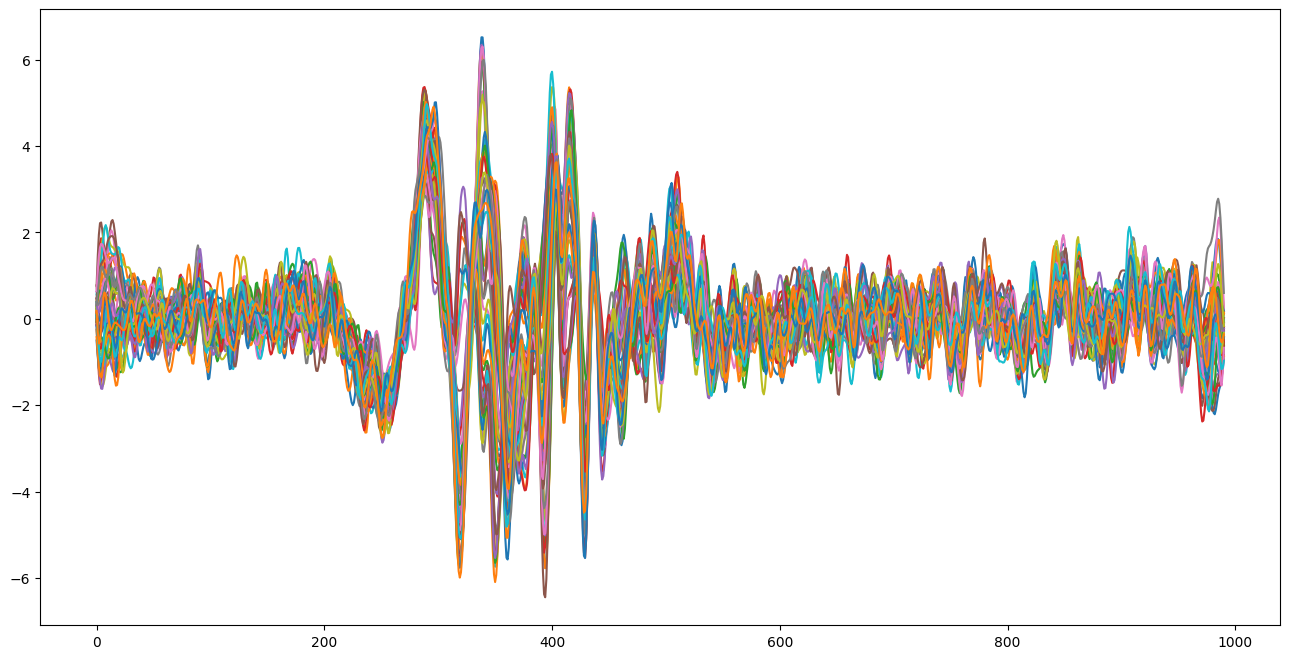

In [10]:
new_csi_data = reshaping(df["CSI_processed"], selection_result['best_band'])
plt.figure(figsize=(16,8))
plt.plot(new_csi_data[0])
plt.show()


### Selecting the quietest window, choosing a qualitative 12-subcarriers band, calculating a fixed threshold, based on the 95 percentile of moving amplitude variance for each subcarrier and mutiplied by a factor (1.1 in this case), detecting all windows having the metric above the fixed threshold, applying weights via the gaussian function and finally choosing the window with the haighest metric value.

In [11]:
sample = df["CSI_processed"][0]
if df.columns.isin(["event_start","event_end"]).any():
    joined_csi = join_idle_states(df, index=0)
    result = complete_nbvi_calibration(joined_csi, apply_noise_gate_band=False, window_size=300, step=25, percentile=5, mvs_window_size=100, method="amplitude")
    step=10
    print(result['threshold'])
    print(result['best_band'])
    candidate_windows=[]
    candidate_windows, variances, p_threshold = find_candidate_windows(sample, window_size=300, band=result['best_band'], step=step, threshold=result['threshold'], quietest=False, method="amplitude", weighted=True, sigma=12)
    print("candidate window: ", candidate_windows)
    if len(candidate_windows) > 0 :
        if df.columns.isin(["event_start","event_end"]).any():
            best_index_window = np.argmax([window[2] for window in candidate_windows])
            plot_variance(candidate_windows[best_index_window], variances, p_threshold, step=step)
            print("Time distance index: ",abs((candidate_windows[best_index_window][0]-df["event_start"][0]+candidate_windows[best_index_window][1]-df["event_end"][0])//2))
    else :
        print("NO MOTION WINDOW HAS BEEN DETECTED")
else :
    print("Calibration is not available because no event_start and event_end columns name were found in the dataframe, not enabling the creation of an idle state !")

Calibration is not available because no event_start and event_end columns name were found in the dataframe, not enabling the creation of an idle state !


### Calculating the distance in packets between the manually-indexed center window and the automatically-indexed center window for all the samples of the dataframe, based on the methods and parameters specified in the mean_time_differences() function.

In [12]:
if df.columns.isin(["event_start","event_end"]).any():
    print(df[df["ambiguous_event"]].index.tolist())
    mean_time_difference, nb_no_motion_detected = mean_time_differences(df, all_subcarriers=True, gain_locked=True, apply_noise_gate_band=False, window_detection_size=300, factor=1.1, percentile_detection=35, sigma=12, method="amplitude", calibration=False, weighted=True)
    print(f"Mean of time difference between the centers in packets: {mean_time_difference} with {nb_no_motion_detected} samples without detection of motion")
else :
    print("Calculating the mean packets difference is not possible because no event_start and event_end columns name were found in the dataframe, not enabling the creation of an idle state !")

Calculating the mean packets difference is not possible because no event_start and event_end columns name were found in the dataframe, not enabling the creation of an idle state !


### Saving the start index and end index of the automatically-indexed window respectively in a "event_start" and "event_end" columns for all the samples of the dataframe, based on the methods and parameters specified in the create_filtered_database() function. A "type_annotation" column is also add, equal to 'manually' for each sample per default and equal to 'automatically' when the algorithm is ran for a sample.

In [13]:
new_df = create_filtered_database(df,  gain_locked=True, all_subcarriers=True, apply_noise_gate_band=False, window_calibration_size=300, window_detection_size=300, mvs_window_size=100, step_calibration=25, step_detection=10, factor=1.1, percentile_calibration=5, percentile_detection=35, method="turbulence",calibration=False, weighted=True, sigma=12)
# Save the new DataFrame to the new file
print(new_file_path)
new_df.to_pickle(new_file_path)
print(f"New database saved as: {new_file_path}")

Annotating the samples by finding the best movement window for each of them...
..\data\26_05_21.pkl_annotated_automatically_indexed.pkl
New database saved as: ..\data\26_05_21.pkl_annotated_automatically_indexed.pkl
